In [1]:
import cv2

img = cv2.imread("../input/landuse-scene-classification/images_train_test_val/test/beach/beach_000022.png")

img.shape

(256, 256, 3)

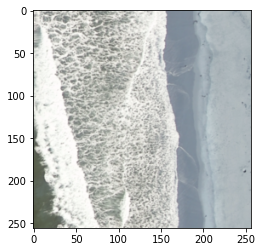

In [2]:
import matplotlib.pyplot as plt

plt.imshow(img)

In [3]:
train_dir = "../input/landuse-scene-classification/images_train_test_val/train"
test_dir = "../input/landuse-scene-classification/images_train_test_val/test"
val_dir = "../input/landuse-scene-classification/images_train_test_val/validation"

In [4]:
# processing the data 

import tensorflow as tf

train_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1/255.)

test_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1/255.)

val_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1/255.)


In [5]:
# creating datasets

train_data = train_gen.flow_from_directory(train_dir,
                                           target_size = (224,224),
                                           class_mode = "categorical",
                                           batch_size = 32
                                           )

test_data = test_gen.flow_from_directory(test_dir,
                                         target_size = (224,224),
                                         class_mode = "categorical",
                                         batch_size = 32
                                         )
val_data = val_gen.flow_from_directory(val_dir,
                                       target_size = (224,224),
                                       class_mode = "categorical",
                                       batch_size = 32
                                       )

Found 7350 images belonging to 21 classes.
Found 1050 images belonging to 21 classes.
Found 2100 images belonging to 21 classes.


In [6]:
image, label = train_data.next()
print(image.shape)
print(label.shape)

(32, 224, 224, 3)
(32, 21)


In [7]:
class_label = list(train_data.class_indices.keys())


2021-11-22 17:15:57.885353: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-22 17:15:57.984730: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-22 17:15:57.985511: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-22 17:15:57.987351: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

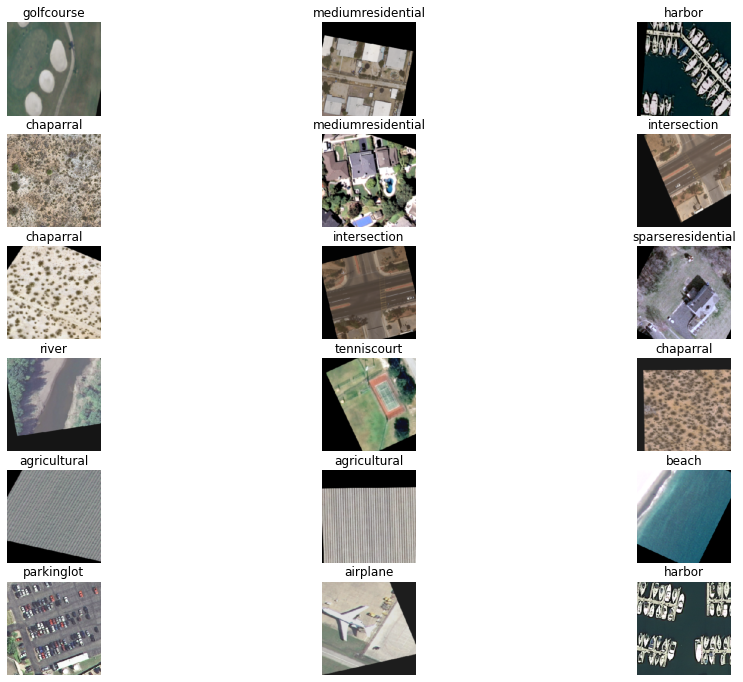

In [8]:
# visualizing the train dataset

import matplotlib.pyplot as plt
import tensorflow as tf

plt.figure(figsize=(16,12))

image, label = train_data.next()
for i in range(18):
  plt.subplot(6,3,i+1)
  plt.imshow(image[i])
  plt.title(class_label[tf.argmax(label[i])])

  plt.axis("off")


In [9]:
# building a CNN model

import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
                             layers.Conv2D(filters= 32, kernel_size= 2, activation="relu", input_shape=(224,224,3)),
                             layers.MaxPooling2D(pool_size= 2),

                             layers.Conv2D(filters = 32, kernel_size= 2, activation="relu"),
                             layers.MaxPooling2D(pool_size= 2),

                             layers.Conv2D(filters= 32, kernel_size= 2, activation= "relu"),
                             layers.MaxPooling2D(pool_size=2),

                             layers.Conv2D(filters= 32, kernel_size= 2, activation= "relu"),
                             layers.MaxPooling2D(pool_size=2),

                            
                             layers.Conv2D(filters= 32, kernel_size= 2, activation= "relu"),
                             layers.Conv2D(filters= 32, kernel_size= 2, activation= "relu"),
                             layers.Conv2D(filters= 32, kernel_size= 2, activation= "relu"),

                             layers.Flatten(),

                             layers.Dense(256, activation="relu"),

                             layers.Dense(21, activation="softmax")


])

In [10]:
# compiling the model

model.compile(
    loss = tf.keras.losses.categorical_crossentropy,
    optimizer = tf.keras.optimizers.Adam(learning_rate= 0.001),
    metrics = ["accuracy"]
)

In [11]:
# fitting data to the model

model.fit(train_data,
          epochs = 5,
          steps_per_epoch = len(train_data),
          validation_data = val_data,
          validation_steps = len(val_data)
          )

2021-11-22 17:16:01.739906: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/5


2021-11-22 17:16:03.343064: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


230/230 [==============================] - 99s 401ms/step - loss: 2.6688 - accuracy: 0.1464 - val_loss: 2.2739 - val_accuracy: 0.2595
Epoch 2/5
230/230 [==============================] - 45s 197ms/step - loss: 1.9768 - accuracy: 0.3585 - val_loss: 1.8132 - val_accuracy: 0.3871
Epoch 3/5
230/230 [==============================] - 44s 192ms/step - loss: 1.5938 - accuracy: 0.4739 - val_loss: 1.5921 - val_accuracy: 0.4657
Epoch 4/5
230/230 [==============================] - 44s 191ms/step - loss: 1.3322 - accuracy: 0.5596 - val_loss: 1.4625 - val_accuracy: 0.5186
Epoch 5/5
230/230 [==============================] - 44s 193ms/step - loss: 1.0961 - accuracy: 0.6346 - val_loss: 1.3997 - val_accuracy: 0.5486


In [12]:
model_evaluation = model.evaluate(test_data)

33/33 [==============================] - 11s 323ms/step - loss: 1.3571 - accuracy: 0.5581


In [13]:
print(f"Model Accuarcy: {model_evaluation[1] * 100: 0.2f} %")

Model Accuarcy:  55.81 %


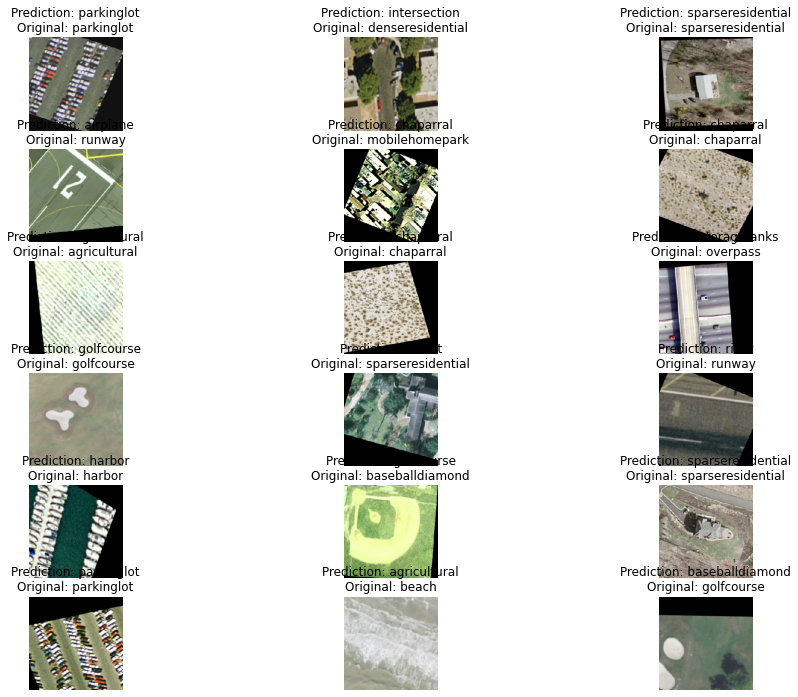

In [14]:
#visualizing the prediction
import matplotlib.pyplot as plt
import tensorflow as tf

plt.figure(figsize=(16,12))

image, label = test_data.next()
for i in range(18):
  model_pred = model.predict(image)
  plt.subplot(6,3,i+1)
  plt.imshow(image[i])
  plt.title(f"Prediction: {class_label[tf.argmax(model_pred[i])]}\nOriginal: {class_label[tf.argmax(label[i])]}")

  plt.axis("off")


In [15]:
# processing the data for efficientnet


train_eff = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                     label_mode = "categorical",
                                                                     image_size = (224,224),
                                                                     batch_size = 32
                                                                    
                                                                     )

test_eff = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                   label_mode = "categorical",
                                                                   image_size = (224,224),
                                                                   batch_size = 32
                                                                   
                                                                   )
val_eff = tf.keras.preprocessing.image_dataset_from_directory(val_dir,
                                                                   label_mode = "categorical",
                                                                   image_size = (224,224),
                                                                   batch_size = 32
                                                                   
                                                                   )

Found 7350 files belonging to 21 classes.
Found 1050 files belonging to 21 classes.
Found 2100 files belonging to 21 classes.


In [16]:
# building model for efficientnet50
import tensorflow as tf

eff_base = tf.keras.applications.EfficientNetB5(include_top= False)

eff_base.trainable = False

115277824/115263384 [==============================] - 2s 0us/step


In [17]:
#buildinb resnet model
from tensorflow.keras import layers

inputs = tf.keras.Input(shape=(224,224,3))

x = eff_base(inputs)

x = layers.GlobalAveragePooling2D()(x)

outputs = layers.Dense(21, activation="softmax")(x)

eff_model = tf.keras.Model(inputs, outputs)

In [18]:
# compiling the model

eff_model.compile(
    loss = tf.keras.losses.categorical_crossentropy,
    optimizer = tf.keras.optimizers.Adam(learning_rate= 0.001),
    metrics = ["accuracy"]
)

In [19]:
# fitting data to the model

eff_model.fit( train_eff,
             epochs = 5,
             steps_per_epoch = len(train_eff),
             validation_data = val_eff,
             validation_steps = len(val_eff)
             )

Epoch 1/5
230/230 [==============================] - 57s 194ms/step - loss: 0.8592 - accuracy: 0.8197 - val_loss: 0.3803 - val_accuracy: 0.9157
Epoch 2/5
230/230 [==============================] - 42s 177ms/step - loss: 0.2856 - accuracy: 0.9385 - val_loss: 0.2554 - val_accuracy: 0.9367
Epoch 3/5
230/230 [==============================] - 43s 180ms/step - loss: 0.1979 - accuracy: 0.9567 - val_loss: 0.2012 - val_accuracy: 0.9500
Epoch 4/5
230/230 [==============================] - 42s 178ms/step - loss: 0.1555 - accuracy: 0.9657 - val_loss: 0.1713 - val_accuracy: 0.9552
Epoch 5/5
230/230 [==============================] - 41s 177ms/step - loss: 0.1253 - accuracy: 0.9746 - val_loss: 0.1500 - val_accuracy: 0.9605


In [20]:
# tunning the model

eff_base.trainable = True

for layer in eff_base.layers[:-3]:
  eff_base.trainable = False

eff_model.compile(
    loss = tf.keras.losses.categorical_crossentropy,
    optimizer = tf.keras.optimizers.Adam(learning_rate= 0.001),
    metrics = ["accuracy"]
)

eff_model.fit(train_eff,
              epochs = 5,
              steps_per_epoch = len(train_eff),
              validation_data = val_eff,
              validation_steps = len(val_eff))

Epoch 1/5
230/230 [==============================] - 57s 196ms/step - loss: 0.1069 - accuracy: 0.9755 - val_loss: 0.1277 - val_accuracy: 0.9657
Epoch 2/5
230/230 [==============================] - 44s 182ms/step - loss: 0.0821 - accuracy: 0.9830 - val_loss: 0.1132 - val_accuracy: 0.9681
Epoch 3/5
230/230 [==============================] - 42s 180ms/step - loss: 0.0698 - accuracy: 0.9867 - val_loss: 0.1024 - val_accuracy: 0.9671
Epoch 4/5
230/230 [==============================] - 44s 185ms/step - loss: 0.0566 - accuracy: 0.9902 - val_loss: 0.0951 - val_accuracy: 0.9738
Epoch 5/5
230/230 [==============================] - 41s 176ms/step - loss: 0.0522 - accuracy: 0.9883 - val_loss: 0.0922 - val_accuracy: 0.9719


In [21]:
print(f"Efficient Accuracy {eff_model.evaluate(val_eff)[1] * 100 : 0.2f} %")

66/66 [==============================] - 10s 133ms/step - loss: 0.0922 - accuracy: 0.9719
Efficient Accuracy  97.19 %


In [22]:
labels_name = test_eff.class_names
len(labels_name)

21

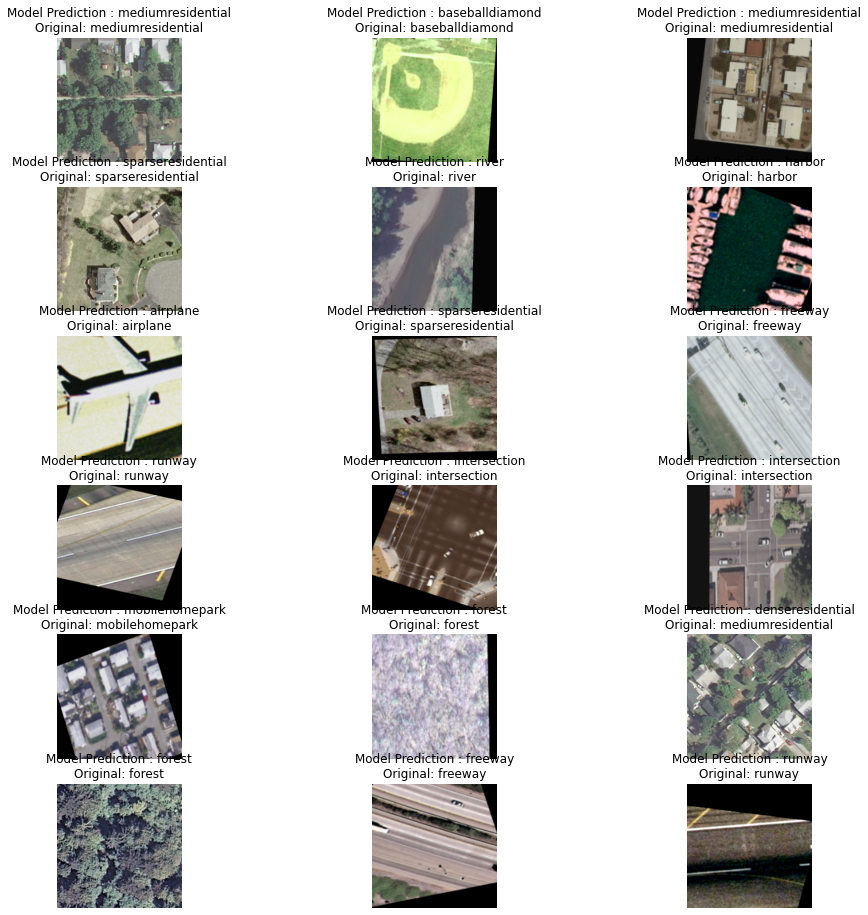

In [23]:
# predicting and visualizing the images

import tensorflow as tf
import matplotlib.pyplot as plt

plt.figure(figsize = (16,16))

for image,label in test_eff.take(1):
  model_prediction = eff_model.predict(image)

  for i in range(18):
    plt.subplot(6,3,i+1)
    plt.imshow(image[i].numpy().astype("uint8"))
    plt.title(f"Model Prediction : {labels_name[tf.argmax(tf.round(model_prediction[i]))]}\nOriginal: {labels_name[tf.argmax(label[i])]}")
    plt.axis("off")